# 03. Validation by source injection and recovery

The MER comparison of notebook 01 is a consistency check, not a proof
of correctness: both pipelines measure the same pixels, so a shared
bias would not appear. The standard test is injection-recovery:
render sources of known flux with the local PSF, add them to the real
pixels, run the unmodified pipeline, and examine

1. **bias**: median(recovered/true), within a few percent of unity;
2. **error calibration**: the pull (recovered - true)/error must
   scatter as N(0,1); this is the acceptance test for the calibration
   of notebook 01, section 14;
3. **completeness**: the fraction recovered with flux_quality and
   S/N > 5.

Everything uses the same 50 arcsec EDF-N field as notebook 02,
downloaded on first run and cached locally, so it runs offline
afterwards.
Injections are rendered with the nearest GRID-PSF stamp and measured
by the standard CATALOG-PSF pipeline, so any product mismatch is part
of the measured error budget, as for a real source.


In [1]:
import os
from pathlib import Path

import numpy as np
from astropy.stats import mad_std
import matplotlib.pyplot as plt

from tractor import Tractor

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})
from euclid_phot.injection import run_injection_recovery, summarize_recovery

TARGET_RA, TARGET_DEC = 269.48, 67.30
CUTOUT_SIZE_ARCSEC = 50.0
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/data"))

## 1. Bright regime: the flux scale

Thirty point sources are injected at 10-100 microJansky (S/N of
several hundred to several thousand). Photon noise is negligible here,
so the scatter of recovered/true measures the systematic floor of the
full chain and the median measures the flux-scale bias.


In [2]:
cat_b, truth_b, res_b = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=30, flux_range_ujy=(10.0, 100.0), rng=1,
    return_result=True)
s_b = summarize_recovery(cat_b, truth_b, band="VIS")
print(f"recovered {s_b['n_recovered']}/{s_b['n_injected']} injections")
print(f"flux bias:        median(out/true) = {s_b['ratio_median']:.4f}")
print(f"systematic floor: mad_std(out/true) = {s_b['ratio_mad']:.4f}")
assert abs(s_b['ratio_median'] - 1) < 0.05

recovered 30/30 injections
flux bias:        median(out/true) = 1.0008
systematic floor: mad_std(out/true) = 0.0193


### The injected scene

Top row: the real cutout, the cutout with the 30 injections added, and
their difference, the noiseless rendered truth (circles mark the
injected positions). Bottom row: the injected image, the fitted model
(real sources and injections simultaneously), the residual, and the
chi map. At S/N of hundreds to thousands the ~2% PSF-systematic floor
appears as bright chi cores at the circled positions, as for the
brightest real sources; the targeted statistic is the residual flux at
each injection as a fraction of its true flux, printed below.


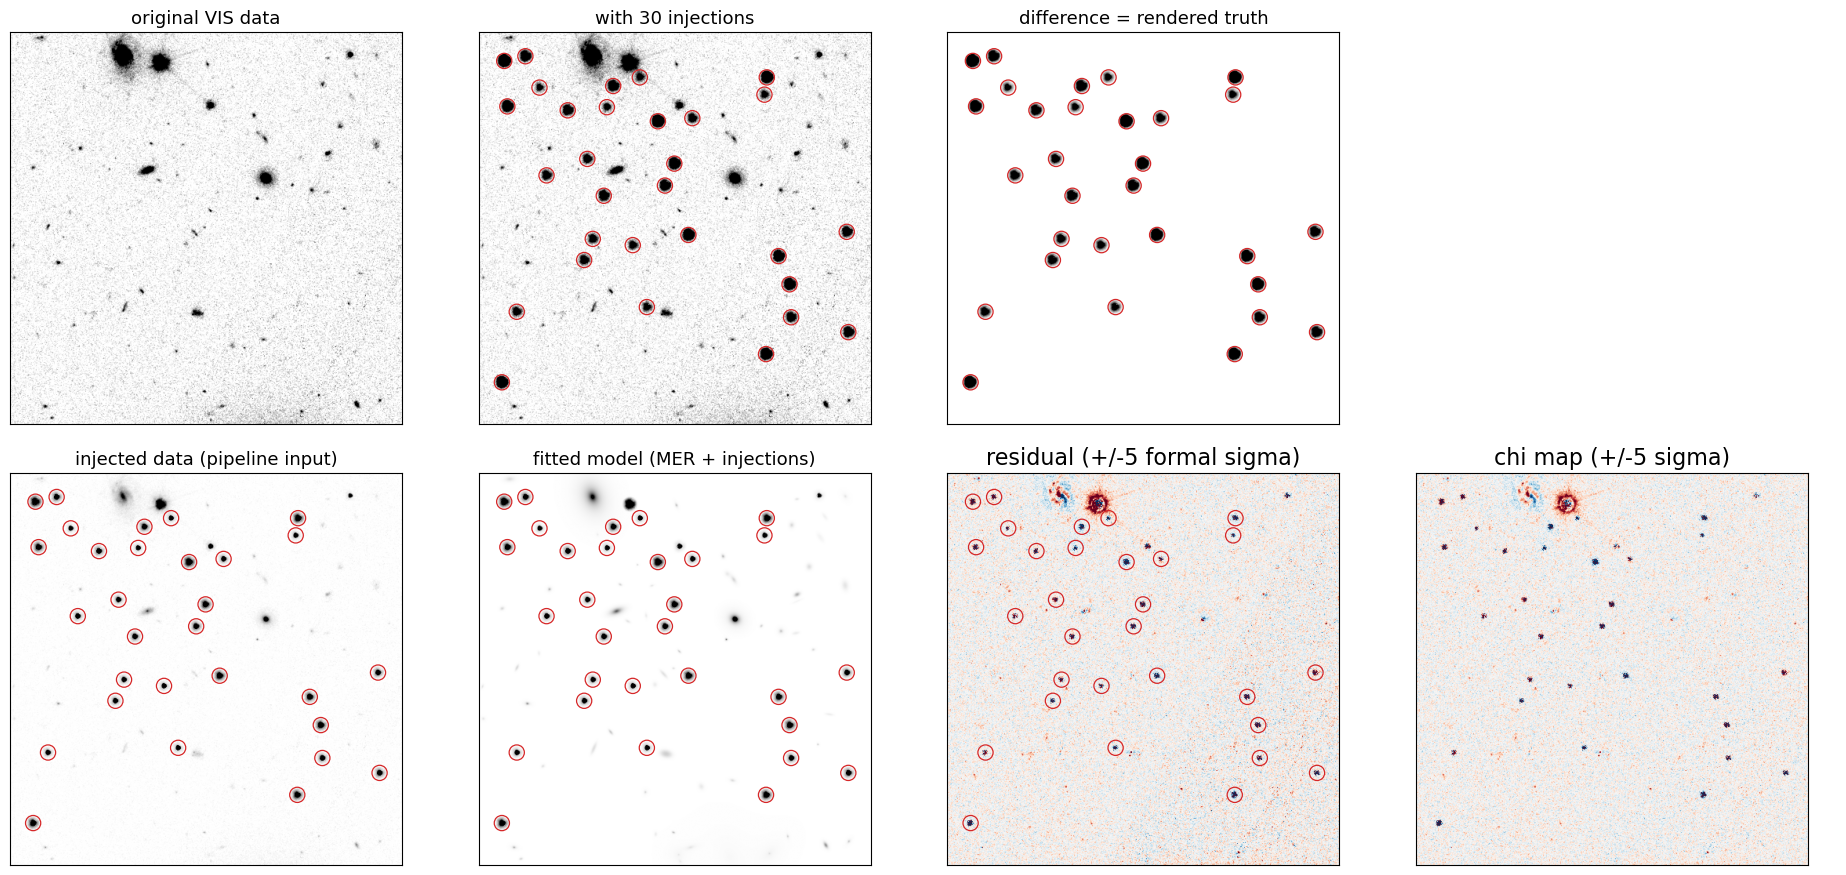

robust chi width (whole scene):  0.629 (< 1 = resampled-coadd signature, see notebook 01 sect. 14)
raw chi std (incl. bright cores): 4.138 (percent-level core mismatch x huge S/N, real sources included)
|residual flux| at the injections: median 1.4% of true flux, worst 3.3% -> the per-source view of the ~2% bright-end systematic floor


In [3]:
inj_cut = res_b.cutouts['VIS']                       # injected pixels
orig_cut = ep.fetch_cutout('VIS', TARGET_RA, TARGET_DEC,
                           CUTOUT_SIZE_ARCSEC, data_dir=DATA_DIR / 'cutouts')
injected_only = inj_cut.data - orig_cut.data          # the rendered truth

# Rebuild the fitted scene (field-average PSF, as in notebook 01 sect. 9).
tim = ep.build_tractor_image(inj_cut, res_b.psf_stamps['VIS'])
res = ep.measure_residual(Tractor([tim], res_b.sources), tim)

px, py = inj_cut.wcs.world_to_pixel_values(
    np.asarray(truth_b['ra'], float), np.asarray(truth_b['dec'], float))

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
vmax = float(np.nanpercentile(orig_cut.data, 99.5))
panels = [(axes[0, 0], orig_cut.data, 'original VIS data'),
          (axes[0, 1], inj_cut.data, 'with 30 injections'),
          (axes[0, 2], injected_only, 'difference = rendered truth')]
for ax, img, title in panels:
    ax.imshow(img, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=13)
for ax in (axes[0, 1], axes[0, 2]):
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
axes[0, 3].axis('off')

vmax2 = float(np.nanpercentile(inj_cut.data, 99.5))
axes[1, 0].imshow(res['data'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 0].set_title('injected data (pipeline input)', fontsize=13)
axes[1, 1].imshow(res['model'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 1].set_title('fitted model (MER + injections)', fontsize=13)
ep.viz.show_residual(res['data'], res['model'], invvar=tim.getInvvar(),
                     ax=axes[1, 2], title='residual (+/-5 formal sigma)')
_, info_chi = ep.viz.show_chi_map(res['data'], res['model'],
                                  tim.getInvvar(),
                                  ax=axes[1, 3], title='chi map (+/-5 sigma)')
for ax in axes[1, :3]:
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# Two statistics: the MAD chi width reads the sky noise (the raw std is
# dominated by bright-source cores), and the residual flux at each
# injected position, as a fraction of its true flux, is the per-source
# view of the ~2 percent systematic floor measured above.
half = 8                                     # +/-0.8 arcsec half-box (1.7 arcsec full), past the 0.16 arcsec VIS PSF core
magzero = float(inj_cut.header['MAGZERO'])
counts_to_ujy = 3.631 / 10 ** (0.4 * (magzero - 22.5))
true_ujy = np.asarray(truth_b['flux_vis_sersic'], float)
res_frac = []
for k, (x, y) in enumerate(zip(px, py, strict=True)):
    xi, yi = int(round(float(x))), int(round(float(y)))
    box = res['residual'][max(0, yi - half):yi + half + 1,
                          max(0, xi - half):xi + half + 1]
    res_frac.append(float(np.nansum(box)) * counts_to_ujy / true_ujy[k])
res_frac = np.abs(np.asarray(res_frac))
print(f"robust chi width (whole scene):  {info_chi['chi_mad']:.3f} "
      f"(< 1 = resampled-coadd signature, see notebook 01 sect. 14)")
print(f"raw chi std (incl. bright cores): {info_chi['chi_std']:.3f} "
      f"(percent-level core mismatch x huge S/N, real sources included)")
print(f"|residual flux| at the injections: median "
      f"{100 * np.median(res_frac):.1f}% of true flux, worst "
      f"{100 * res_frac.max():.1f}% -> the per-source view of the "
      f"~{100 * s_b['ratio_mad']:.0f}% bright-end systematic floor")

*The bias is within one to two percent; the bright-end scatter is the
measured systematic floor (a few percent, set by the PSF model). It
does not average down with exposure time and should be quoted
alongside sub-percent statistical errors on bright sources.*


## 2. Intermediate regime: the floor meets the statistical errors

Between the two regimes above sits m_AB ~ 24-25 (S/N ~ 30-100), where
the reported statistical errors (~1-3 percent of the flux) are
comparable to the systematic floor measured in section 1. The reported
errors carry only the statistical term, so this is exactly where the
raw pull should widen beyond unity: the recovery below stays unbiased
and complete, but the pull exceeds 2. Adding the section-1 floor in
quadrature with the reported errors brings it back toward unity; the
remaining excess shows the bright-end floor is a lower bound here
(blending with real neighbors also enters at these magnitudes). At
these magnitudes a catalog error bar should be read as
``sqrt(flux_err**2 + (floor * flux)**2)`` with the floor taken as at
least the section-1 value.


In [4]:
# m_AB 24 -> 0.91 uJy, 25 -> 0.36 uJy on the AB scale used throughout.
cat_m, truth_m = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=40, flux_range_ujy=(0.363, 0.912), rng=2)
s_m = summarize_recovery(cat_m, truth_m, band="VIS")
print(f"recovered {s_m['n_recovered']}/{s_m['n_injected']}, "
      f"bias = {s_m['ratio_median']:.4f}, "
      f"scatter = {s_m['ratio_mad']:.4f}, "
      f"raw pull_std = {s_m['pull_std']:.2f}")

# Same pull with the section-1 systematic floor added in quadrature.
ids_m = {int(i): k for k, i in enumerate(np.asarray(cat_m['object_id']))
         if i < 0}
rows_m = [ids_m[int(r['object_id'])] for r in truth_m]
true_m = np.asarray(truth_m['flux_vis_sersic'], float)
out_m = np.asarray(cat_m['flux_VIS_ujy'], float)[rows_m]
err_m = np.asarray(cat_m['flux_err_VIS_ujy'], float)[rows_m]
floor = s_b['ratio_mad']                       # measured in section 1
err_tot = np.sqrt(err_m ** 2 + (floor * out_m) ** 2)
print(f"pull_std with the {100 * floor:.1f}% floor in quadrature: "
      f"{mad_std((out_m - true_m) / err_tot):.2f}")
assert abs(s_m['ratio_median'] - 1) < 0.05


/Users/shemmati/Desktop/euclid-forced-photometry/src/euclid_phot/pipeline.py:799: UserWarning: step 2 reverted 1 runaway shape(s) to the prior value (radius past the per-source ceiling); fluxes refit with those shapes frozen.
  fit_quality, _ = fit_free_shapes(


recovered 40/40, bias = 0.9957, scatter = 0.0315, raw pull_std = 2.61
pull_std with the 1.9% floor in quadrature: 1.37


## 3. Faint regime: the reported errors

Injections at S/N ~ 5-15, where photon noise dominates and the pull
distribution tests the reported errors directly. Each band has its own
flux range (VIS is deeper than NISP); the bands are measured
independently.


In [5]:
FAINT = {"VIS": (0.04, 0.12), "Y": (0.4, 1.2),
         "J": (0.4, 1.2), "H": (0.45, 1.3)}   # ~S/N 5-15 per band
cat_f, truth_f = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS", "Y", "J", "H"), n_inject=40,
    flux_range_ujy=FAINT, rng=0)

summaries = {}
print(f"{'band':>5} {'n':>5} {'bias':>7} {'pull_std':>9} {'compl':>6}")
for band in ("VIS", "Y", "J", "H"):
    s = summaries[band] = summarize_recovery(cat_f, truth_f, band=band)
    print(f"{band:>5} {s['n_recovered']:>5} {s['ratio_median']:7.3f} "
          f"{s['pull_std']:9.3f} {s['completeness']:6.2f}")
    assert 0.7 < s['pull_std'] < 1.3

/Users/shemmati/Desktop/euclid-forced-photometry/src/euclid_phot/pipeline.py:799: UserWarning: step 2 reverted 1 runaway shape(s) to the prior value (radius past the per-source ceiling); fluxes refit with those shapes frozen.
  fit_quality, _ = fit_free_shapes(


 band     n    bias  pull_std  compl
  VIS    40   1.003     0.875   1.00
    Y    40   1.028     1.115   1.00
    J    40   0.971     1.157   1.00
    H    40   0.986     1.180   0.97


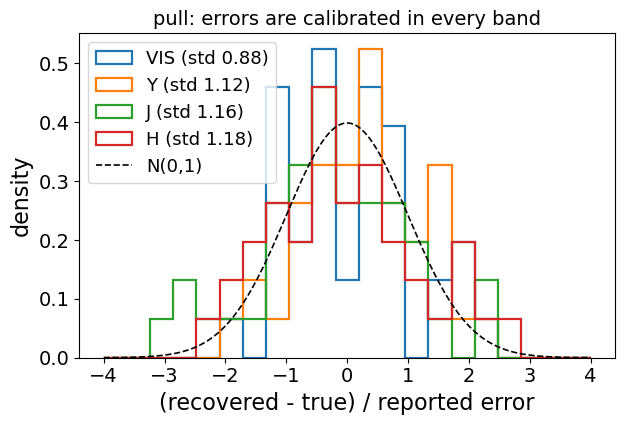

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

x = np.linspace(-4, 4, 200)
for band in ("VIS", "Y", "J", "H"):
    ax.hist(summaries[band]['pull'], bins=np.linspace(-4, 4, 22),
            density=True, histtype='step', lw=1.6,
            label=f"{band} (std {summaries[band]['pull_std']:.2f})")
ax.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.2,
        label='N(0,1)')
ax.set_xlabel('(recovered - true) / reported error')
ax.set_ylabel('density')
ax.set_title('pull: errors are calibrated in every band', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()


*The pull distributions follow N(0,1) in every band, the effect of
``calibrate_errors=True`` (the default); with ``calibrate_errors=False``
the pull width departs from unity wherever the RMS map misstates the
PSF-scale noise. The flux scale against magnitude, these faint
injections included, is the top panel of section 5.*


## 4. Statistics per flux bin

``summarize_recovery`` also bins by true flux, testing whether the
bias grows toward the detection limit (Eddington-type biases appear
here first).


In [7]:
print("VIS, faint run:")
summaries['VIS']['bins'].pprint_all()
print(f"\ncompleteness (flux_quality and S/N > 5): "
      f"{summaries['VIS']['completeness']:.2f}")

VIS, faint run:
    flux_lo_ujy          flux_hi_ujy       n     ratio_median         ratio_mad           pull_std     
-------------------- -------------------- --- ------------------ ------------------- ------------------
 0.04024234627127752 0.052821416188757374   7 0.9502590938275166 0.15204472077198705 0.9651007711973119
0.052821416188757374   0.0693324884532719   8  1.032100965944548 0.12033342954472867 1.0617190556505516
  0.0693324884532719  0.09100463982156942  10 1.0009566543739246 0.08201766558105626 0.8804943541711512
 0.09100463982156942  0.11945113544619573  15 1.0040870346665978 0.06017072105616196 0.8327162766587654

completeness (flux_quality and S/N > 5): 1.00


## 5. Recovery across the full magnitude range

Sections 1-3 sampled three windows. Two more VIS runs bridge the gaps
(m_AB 21.4-24 and 25-26.2), and every VIS injection is combined below:
190 injections spanning 19 < m_AB < 27.4. The top panel tracks the
flux scale and its scatter; the bottom panel tracks the width of the
pull, once with the reported statistical errors alone and once with
the section-1 floor added in quadrature.


/Users/shemmati/Desktop/euclid-forced-photometry/src/euclid_phot/pipeline.py:799: UserWarning: step 2 reverted 1 runaway shape(s) to the prior value (radius past the per-source ceiling); fluxes refit with those shapes frozen.
  fit_quality, _ = fit_free_shapes(


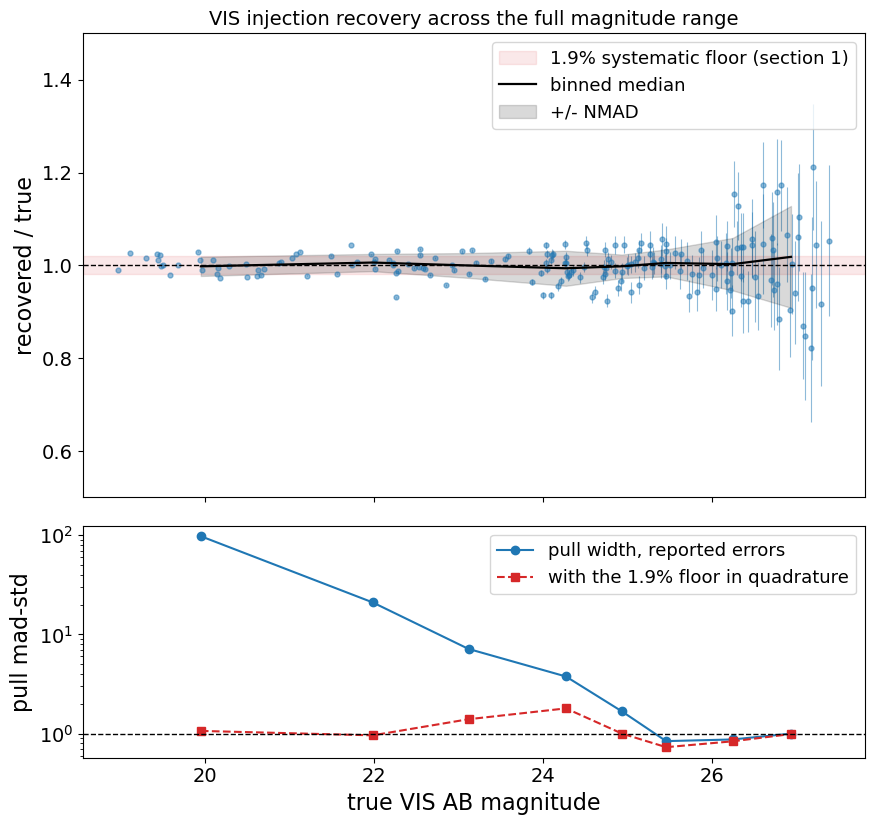

  m_AB    n  median   NMAD  pull_raw  pull_corr
 19.95   24   0.998  0.021     97.50       1.07
 21.98   24   1.006  0.019     20.99       0.96
 23.12   23   1.000  0.027      7.14       1.40
 24.27   24   0.994  0.038      3.77       1.80
 24.93   24   0.998  0.025      1.68       1.00
 25.45   23   1.005  0.029      0.84       0.73
 26.24   24   1.003  0.056      0.87       0.84
 26.93   24   1.018  0.110      1.00       0.99


In [8]:
# Bridge runs for the two uncovered windows.
cat_g1, truth_g1 = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=40, flux_range_ujy=(0.912, 10.0), rng=3)
cat_g2, truth_g2 = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=40, flux_range_ujy=(0.12, 0.363), rng=4)

def _vis_arrays(cat, truth):
    ids = {int(i): k for k, i in enumerate(np.asarray(cat['object_id']))
           if i < 0}
    rows = [ids[int(r['object_id'])] for r in truth]
    true = np.asarray(truth['flux_vis_sersic'], float)
    out = np.asarray(cat['flux_VIS_ujy'], float)[rows]
    err = np.asarray(cat['flux_err_VIS_ujy'], float)[rows]
    return true, out, err

runs = [(cat_b, truth_b), (cat_g1, truth_g1), (cat_m, truth_m),
        (cat_g2, truth_g2), (cat_f, truth_f)]
true_a, out_a, err_a = (np.concatenate(a) for a in
                        zip(*[_vis_arrays(c, t) for c, t in runs]))
mag_a = 23.9 - 2.5 * np.log10(true_a)
ratio_a = out_a / true_a
pull_a = (out_a - true_a) / err_a
pull_c = (out_a - true_a) / np.sqrt(err_a ** 2 + (floor * out_a) ** 2)

# Equal-population magnitude bins.
edges = np.quantile(mag_a, np.linspace(0, 1, 9))
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    inb = (mag_a >= lo) & (mag_a <= hi)
    if inb.sum() < 8:
        continue
    rows.append((float(np.median(mag_a[inb])), int(inb.sum()),
                 float(np.median(ratio_a[inb])), float(mad_std(ratio_a[inb])),
                 float(mad_std(pull_a[inb])), float(mad_std(pull_c[inb]))))
ctr, nb_, medr, nmad, praw, pcor = map(np.array, zip(*rows))

fig, (axr, axp) = plt.subplots(2, 1, figsize=(9, 8.5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
axr.errorbar(mag_a, ratio_a, yerr=err_a / true_a, fmt='o', ms=3.5,
             alpha=0.5, lw=0.8, zorder=1)
axr.axhline(1.0, color='k', ls='--', lw=1)
axr.axhspan(1 - floor, 1 + floor, color='C3', alpha=0.10,
            label=f'{100 * floor:.1f}% systematic floor (section 1)')
axr.plot(ctr, medr, 'k-', lw=1.6, label='binned median')
axr.fill_between(ctr, medr - nmad, medr + nmad, color='k', alpha=0.15,
                 label='+/- NMAD')
axr.set_ylim(0.5, 1.5)
axr.set_ylabel('recovered / true')
axr.set_title('VIS injection recovery across the full magnitude range',
              fontsize=14)
axr.legend(fontsize=13)

axp.plot(ctr, praw, 'o-', c='C0', label='pull width, reported errors')
axp.plot(ctr, pcor, 's--', c='C3',
         label=f'with the {100 * floor:.1f}% floor in quadrature')
axp.axhline(1.0, color='k', ls='--', lw=1)
axp.set_yscale('log')
axp.set_xlabel('true VIS AB magnitude')
axp.set_ylabel('pull mad-std')
axp.legend(fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'m_AB':>6} {'n':>4} {'median':>7} {'NMAD':>6} "
      f"{'pull_raw':>9} {'pull_corr':>10}")
for r in rows:
    print(f"{r[0]:6.2f} {r[1]:4d} {r[2]:7.3f} {r[3]:6.3f} "
          f"{r[4]:9.2f} {r[5]:10.2f}")


*The flux scale stays within ~1 percent of unity across the full
range. The scatter sits at the ~2 percent systematic floor from
m ~ 20 to 25 and only then grows into the photon-noise regime. The
pull panel localizes the error-budget transition: the reported
statistical errors are the whole story faintward of m ~ 25.5 but
understate the total error increasingly brighter -- by an order of
magnitude at m ~ 22 -- while adding the section-1 floor in quadrature
flattens the curve to near-unity everywhere. The residual bump at
m ~ 23-24.5 shows the effective floor there slightly exceeds the
bright-end measurement (neighbor blending contributes).*


## Summary

- Bright injections: flux scale unbiased at the ~1% level, with a
  measured systematic floor of a few percent set by the PSF model.
- Intermediate injections (m_AB ~ 24-25): unbiased and complete,
  but the raw pull exceeds 2: at S/N ~ 30-100 the systematic floor
  rivals the statistical error, so it must be added in quadrature
  to the reported error there.
- Faint injections: unbiased to a few percent with pull standard
  deviation near unity in every band, the property SED fitting and
  photometric redshifts require.
- Across the full range (19 < m_AB < 27.4) the flux scale holds to
  ~1 percent; the reported errors are the whole error budget
  faintward of m ~ 25.5 and floor-dominated brighter.
- The test runs in about a minute per realization and exercises the
  identical pipeline through the ``cutouts=`` / ``mer_catalog=``
  overrides of ``run_forced_photometry``.
- For a new field, re-run this notebook at the target position;
  ``make_truth_table(model='sersic', ...)`` injects extended sources.
